In [4]:
from control_total_geography.util import Pipeline
import geopandas as gpd
import pandas as pd

p = Pipeline('configs')

In [5]:
new_hct_gdb_path = 'Q:/Projects/2023_Baseyear/Political/control_geographies/control.gdb'
control_hct_layer = 'control_hct26'
new = gpd.read_file(new_hct_gdb_path, layer=control_hct_layer)

c:\Users\jkolberg\PythonProjects\PSRC\control_total_geography\.venv\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts. The processing may be really slow.  You can skip the processing by setting METHOD=SKIP, or only make it analyze counter-clock wise parts by setting METHOD=ONLY_CCW if you can assume that the outline of holes is counter-clock wise defined
  return ogr_read(


In [6]:
control_areas = gpd.read_file(new_hct_gdb_path, layer='control26')

In [7]:
control_areas.columns

Index(['control_id', 'target_id', 'target_name', 'control_name', 'county_id',
       'exclude_from_target', 'rgid', 'geometry'],
      dtype='object')

In [8]:
old_hct_gdb_path = '../luvit_hcts/output/control.gdb'
control_hct_layer = 'control_hct26'
old = gpd.read_file(old_hct_gdb_path, layer=control_hct_layer)

In [9]:
def summarize_hct(gdf,control_areas):
    gdf['hct'] = 0
    gdf.loc[gdf['chct_id']>=1000,'hct'] = 1
    hct_names = gdf.query('hct == 1')['chct_name'].unique()
    gdf['acres'] = gdf['geometry'].area / 4046.86  # Convert square meters to acres
    gdf = gdf.merge(control_areas[['control_id','control_name','rgid','county_id']], left_on='chct_name', right_on='control_name')
    return gdf.query('(chct_name in @hct_names) & (rgid.isin([1,2,3]))').groupby(['county_id','control_id','chct_name','rgid','hct'])[['acres']].sum()
new_gdf = summarize_hct(new, control_areas).rename(columns={'acres': 'new_acres'})
old_gdf = summarize_hct(old, control_areas).rename(columns={'acres': 'luvit_acres'})


In [10]:
gdf = old_gdf.reset_index().merge(new_gdf.reset_index(), on=['county_id','control_id','chct_name','rgid','hct'], how='outer').fillna(0)
gdf['acres_diff'] = gdf['new_acres'] - gdf['luvit_acres']
gdf['acres_pct_diff'] = gdf['acres_diff'] / gdf['luvit_acres'] * 100

In [11]:
gdf.loc[(gdf['hct']==1) & (gdf['county_id']==53033)]

,county_id,control_id,chct_name,rgid,hct,luvit_acres,new_acres,acres_diff,acres_pct_diff
1,53033.0,1.0,Bellevue,1.0,1,58448.870654,46979.489776,-11469.380879,-19.622930
3,53033.0,2.0,Seattle,1.0,1,227907.737302,177722.991518,-50184.745784,-22.019764
5,53033.0,3.0,Auburn,2.0,1,28196.665171,11873.746689,-16322.918482,-57.889535
7,53033.0,4.0,Bothell,2.0,1,14736.579895,16759.091567,2022.511672,13.724431
9,53033.0,5.0,Burien,2.0,1,14932.884647,11151.842713,-3781.041935,-25.320238
11,53033.0,6.0,Federal Way,2.0,1,25493.418992,14674.829355,-10818.589637,-42.436794
13,53033.0,7.0,Issaquah,2.0,1,5223.814115,6018.462142,794.648027,15.212027
15,53033.0,8.0,Kent,2.0,1,38486.119179,39123.413057,637.293879,1.655906
17,53033.0,9.0,Kirkland,2.0,1,38746.154679,23747.649851,-14998.504828,-38.709660
19,53033.0,10.0,Redmond,2.0,1,27892.976148,15196.502895,-12696.473252,-45.518532


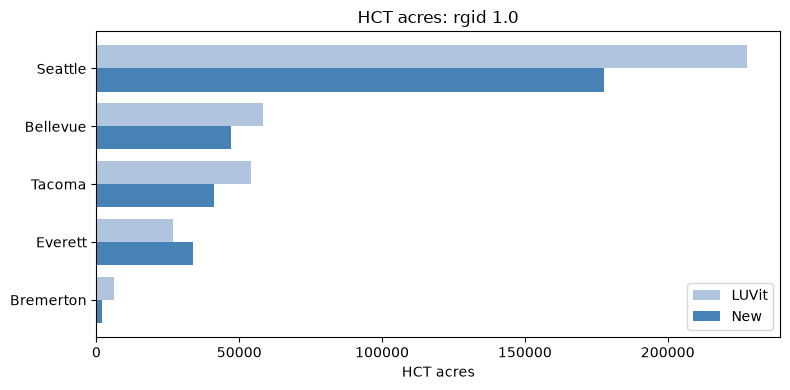

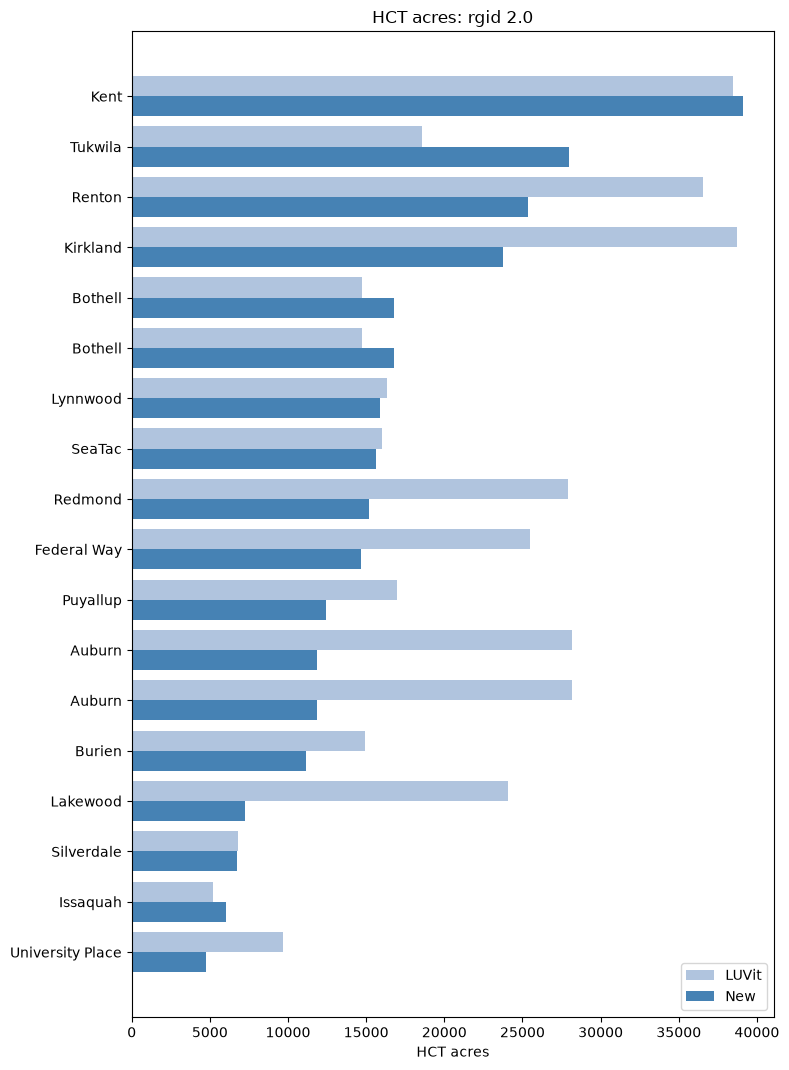

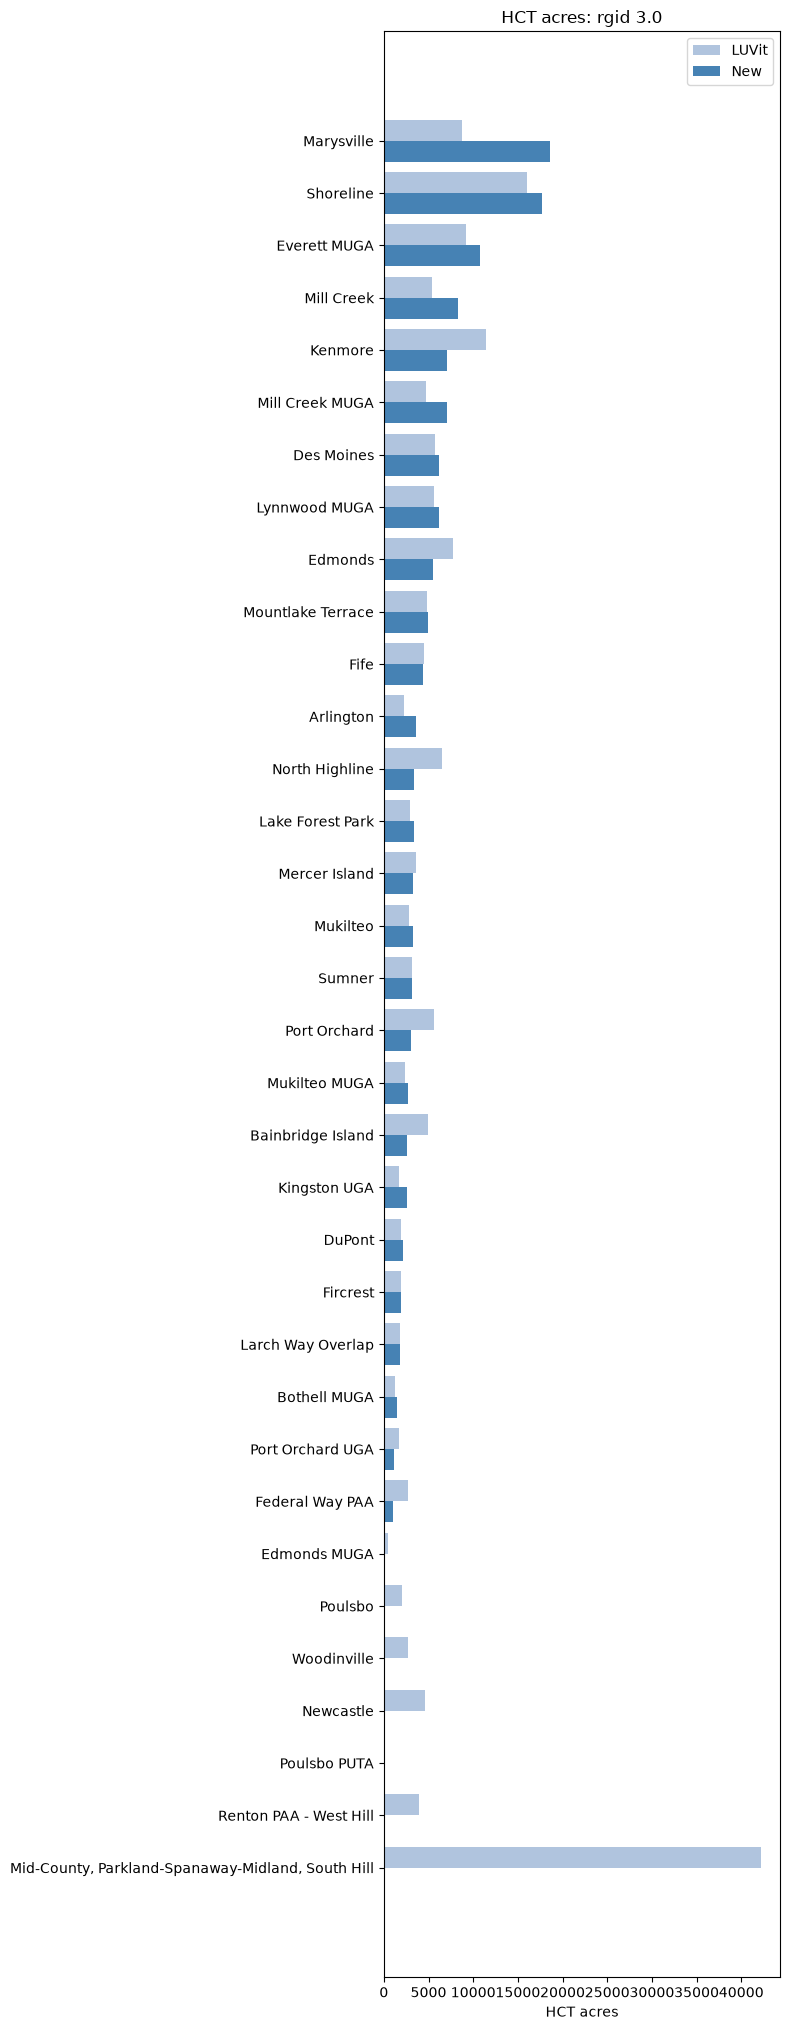

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

plot_dir = Path('output/hct_plots')
plot_dir.mkdir(parents=True, exist_ok=True)

hct_gdf = gdf.loc[gdf['hct'] == 1]
height = 0.4

for rgid, sub in hct_gdf.groupby('rgid'):
    sub = sub.sort_values('new_acres', ascending=False)
    y = np.arange(len(sub))
    fig, ax = plt.subplots(figsize=(8, max(4, 0.6 * len(sub))))
    ax.barh(y - height / 2, sub['luvit_acres'], height, label='LUVit', color='lightsteelblue')  # lighter
    ax.barh(y + height / 2, sub['new_acres'], height, label='New', color='steelblue')
    ax.set_yticks(y)
    ax.set_yticklabels(sub['chct_name'])
    ax.invert_yaxis()  # largest at the top
    ax.set_xlabel('HCT acres')
    ax.set_title(f'HCT acres: rgid {rgid}')
    ax.legend()
    fig.tight_layout()
    fig.savefig(plot_dir / f'hct_acres_rgid_{rgid}.png', dpi=200, bbox_inches='tight')
    plt.show()